# Spectral response

The purpose of this script is to cross check the zero-points and magnitudes of the PLATO N-CAM, F-CAM blue, and F-CAM red response of PlatoSim versus that reported in PLATO-DLR-PL-TN-0113.

Creator: 2024-12-18 - Juan Cabrera 

Updated: 2025-01-07 - Nicholas Jannsen  

Last tested with PlatoSim version develop:
```
commit 7a3f254e05bc0fed4dce1c4c1c690f7e361717c1
Author: Nicholas Jannsen <nicholasemborgjannsen@gmail.com>
Date:   Tue Jan 7 10:29:45 2025 +0100
```

In [1]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# To interact with the plot use
%matplotlib notebook

In [34]:
import os
import scipy
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# PlatoSim
import platosim.plot            as pt
import platosim.utilities       as ut
import platosim.referenceFrames as rf
from platosim.simulation   import Simulation
from platosim.simfile      import SimFile
from platosim.matplotlibrc import setup_notebook
setup_notebook()

## PlatoSim's wavelength dependent parameters

### Applicable documents

- AD-1: PLATO Mission Requirements Document, D. Agnolon
- AD-2: PLATO 01 R BOL, data package v1.7 (normal camera, beginning of life, required), Anko Börner 
- AD-3: PLATO 02 R BOL, data package v1.7 (normal camera, end of life, required), Anko Börner
- AD-5: PLATO 80 FCamB R EOL, data package v1.7 (fast camera, blue, end of life, required), Anko Börner 
- AD-7: PLATO 81 FCamR R EOL, data package v1.7 (fast camera, red, end of life, required), Anko Börner
- AD-8: PLATO-DLR-PL-TN-003 Reference Photon Flux
- AD-9: PLATO-DLR-PL-RP-001 Instrument Noise Budget
- AD-10: PLATO-INAF-PL-RP-001, Telescope Optical Units Performance Analysis report, v2
- AD-11: PLATO-DLR-PL-RP-004, Simulations nad Performance Estimations, v1
- AD-12: PLATO-ESTEC-PL-RS-003, PLATO CCD requirements
- AD-13: Modelling CTI in PLATO-like images, T. Prod’homme, T. Oosterbroek
- AD-14: PLATO-OHV-PL-LI-0009, PLATO Instrument Coordinate Systems
- AD-15: PLATO-KUL-PL-TN-0001, PlatoSim Reference Frames
- AD-16: PLATO-OHB-PL-RS-005, N FEE User Requirements Document, v2
- AD-17: CTI measurements, modelling, requirements, Anko Börner
- AD-18: PLATO-DLR-PL-TN-016: Geometric Camera Model for PLATO TOU
- AD-19: Photometry impacts of Brighter-Fatter Effect (BFE) and CCD  diffusion, Réza Samadi
- AD-20: PLATO-KUL-PL-TN-0003: PLATO FEE readout modes for AIV, Pierre Royer & Ann Baeke

In [26]:
# Reference wavelength of Johnson-Counsin V passband [nm]
refWavelength = 550
print("Reference wavelength:", refWavelength, "nm")

Reference wavelength: 550 nm


### Transmission efficiency (transmissivity of the optics)
Req. 480 in [AD-2] - [AD-7]:
* optics_transmission_1.2pc_bol_cutoff_19-03-31.txt
* optics_transmission_1.2pc_eol_cutoff_19-03-31.txt

In [27]:
# Transmission curves from [450-1050 nm]
wvl = np.arange(450, 1100, 50) 
TE_BOL = np.array([0.7330, 0.7651, 0.7972, 0.8048, 0.8107, 0.8183, 0.8243, 
                   0.8284, 0.8301, 0.8319, 0.8327, 0.8344, 0.8361])
TE_EOL = np.array([0.7039, 0.7379, 0.7719, 0.7835, 0.7918, 0.8018, 0.8076, 
                   0.8125, 0.8142, 0.8158, 0.8175, 0.8183, 0.8191])

# Transform into range [500-1000 nm]
wvl, TE_BOL, TE_EOL = wvl[1:-1], TE_BOL[1:-1], TE_EOL[1:-1]

# As simulated transmission values for F-CAMs
TE_fil_FCAM_blue = 0.986
TE_fil_FCAM_red  = 0.989

Wavelenght range : 500 - 1000 nm:
BOL Transmissivity of N-CAM     : 0.8178
BOL Transmissivity of F-CAM blue: 0.7899
BOL Transmissivity of F-CAM red : 0.8198


<IPython.core.display.Javascript object>


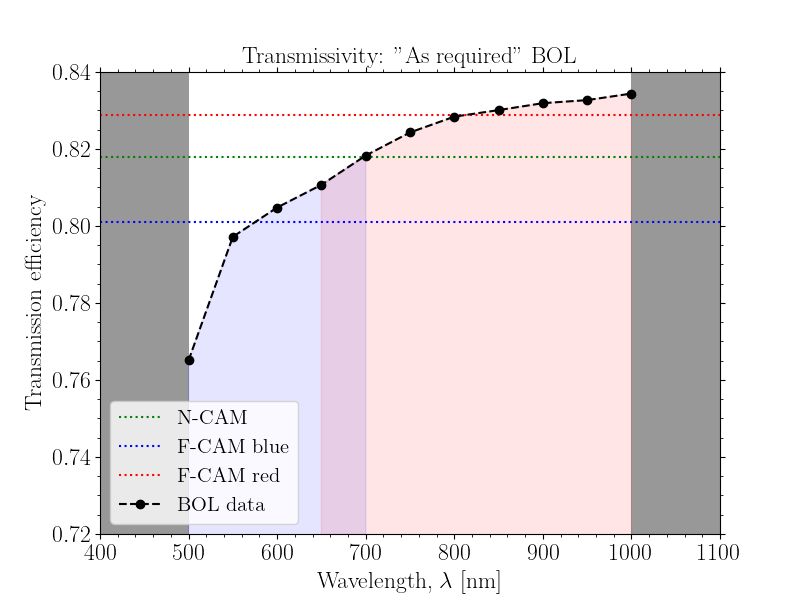

In [30]:
# Mean transmission
TE_BOL_NCAM      = np.trapz(TE_BOL     / (len(TE_BOL)     - 1))
TE_BOL_FCAM_blue = np.trapz(TE_BOL[:5] / (len(TE_BOL[:5]) - 1))
TE_BOL_FCAM_red  = np.trapz(TE_BOL[4:] / (len(TE_BOL[4:]) - 1))
# Print results
print(f"Wavelenght range : {wvl[0]} - {wvl[-1]} nm:")
print(f"BOL Transmissivity of N-CAM     : {TE_BOL_NCAM:.4f}")
print(f"BOL Transmissivity of F-CAM blue: {TE_BOL_FCAM_blue * TE_fil_FCAM_blue:.4f}")
print(f"BOL Transmissivity of F-CAM red : {TE_BOL_FCAM_red  * TE_fil_FCAM_red:.4f}")

plt.figure(figsize=(8,6))
# Plot
plt.axvspan(400, wvl[0],   facecolor='0.2', alpha=0.5)
plt.axvspan(wvl[-1], 1100, facecolor='0.2', alpha=0.5)
plt.fill_between(wvl[:5], TE_BOL[:5], color='blue', alpha=0.1)
plt.fill_between(wvl[3:], TE_BOL[3:], color='red',  alpha=0.1)
plt.axhline(y=TE_BOL_NCAM,      color='g', linestyle=':', label = "N-CAM")
plt.axhline(y=TE_BOL_FCAM_blue, color='b', linestyle=':', label = "F-CAM blue")
plt.axhline(y=TE_BOL_FCAM_red,  color='r', linestyle=':', label = "F-CAM red")
plt.plot(wvl, TE_BOL, "ko--", label = "BOL data")
# Labels
plt.title('Transmissivity: "As required" BOL')
plt.xlabel(r"Wavelength, $\lambda$ [nm]")
plt.ylabel("Transmission efficiency")
# Setting
plt.legend()
plt.xlim(400, 1100)
plt.ylim(0.72, 0.84)
plt.show()

Wavelenght range : 500 - 1000 nm:
EOL Transmissivity of N-CAM     : 0.7995
EOL Transmissivity of F-CAM blue: 0.7684
EOL Transmissivity of F-CAM red : 0.8040


<IPython.core.display.Javascript object>


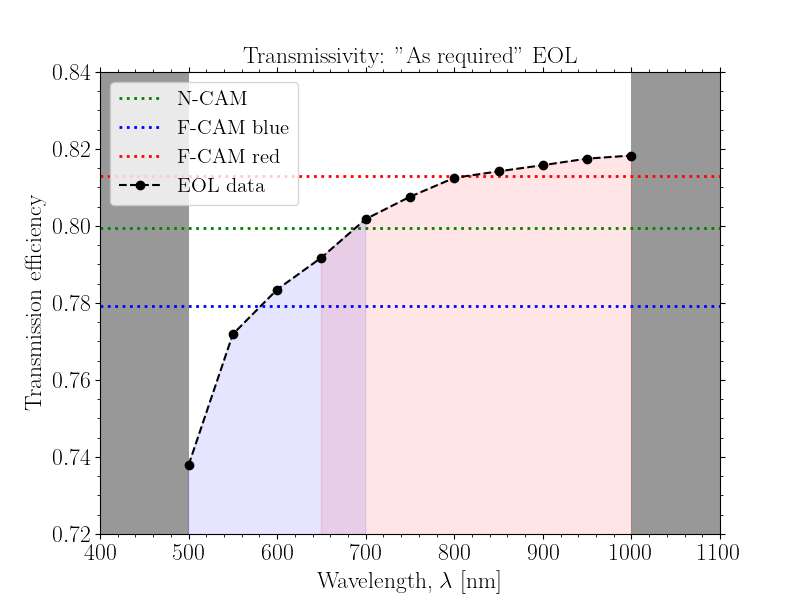

In [31]:
# Mean transmission
TE_EOL_NCAM      = np.trapz(TE_EOL     / (len(TE_EOL)     - 1))
TE_EOL_FCAM_blue = np.trapz(TE_EOL[:5] / (len(TE_EOL[:5]) - 1))
TE_EOL_FCAM_red  = np.trapz(TE_EOL[4:] / (len(TE_EOL[4:]) - 1))
# Print results
print(f"Wavelenght range : {wvl[0]} - {wvl[-1]} nm:")
print(f"EOL Transmissivity of N-CAM     : {TE_EOL_NCAM:.4f}")
print(f"EOL Transmissivity of F-CAM blue: {TE_EOL_FCAM_blue * TE_fil_FCAM_blue:.4f}")
print(f"EOL Transmissivity of F-CAM red : {TE_EOL_FCAM_red  * TE_fil_FCAM_red:.4f}")

plt.figure(figsize=(8,6))
# Plot
plt.axvspan(400, wvl[0],   facecolor='0.2', alpha=0.5)
plt.axvspan(wvl[-1], 1100, facecolor='0.2', alpha=0.5)
plt.fill_between(wvl[:5], TE_EOL[:5], color='blue', alpha=.1)
plt.fill_between(wvl[3:], TE_EOL[3:], color='red',  alpha=.1)
plt.axhline(y=TE_EOL_NCAM,      color='g', linestyle=':', linewidth=2, label = "N-CAM")
plt.axhline(y=TE_EOL_FCAM_blue, color='b', linestyle=':', linewidth=2, label = "F-CAM blue")
plt.axhline(y=TE_EOL_FCAM_red,  color='r', linestyle=':', linewidth=2, label = "F-CAM red")
plt.plot(wvl, TE_EOL, "ko--", label = "EOL data")
# Labels
plt.title('Transmissivity: "As required" EOL')
plt.xlabel(r"Wavelength, $\lambda$ [nm]")
plt.ylabel("Transmission efficiency")
# Setting
plt.legend()
plt.xlim(400, 1100)
plt.ylim(0.72, 0.84)
plt.show()

### Quantum efficiency

"As required": Req. 650 in [AD-2] - [AD-7]: ccd_qe_min_bol_19-03-31.txt 

300
Wavelength range 500 - 1000 nm:
As required QE N-CAM     : 104.3417
As required QE F-CAM blue: 56.5575
As required QE F-CAM red : -373.5760


<IPython.core.display.Javascript object>


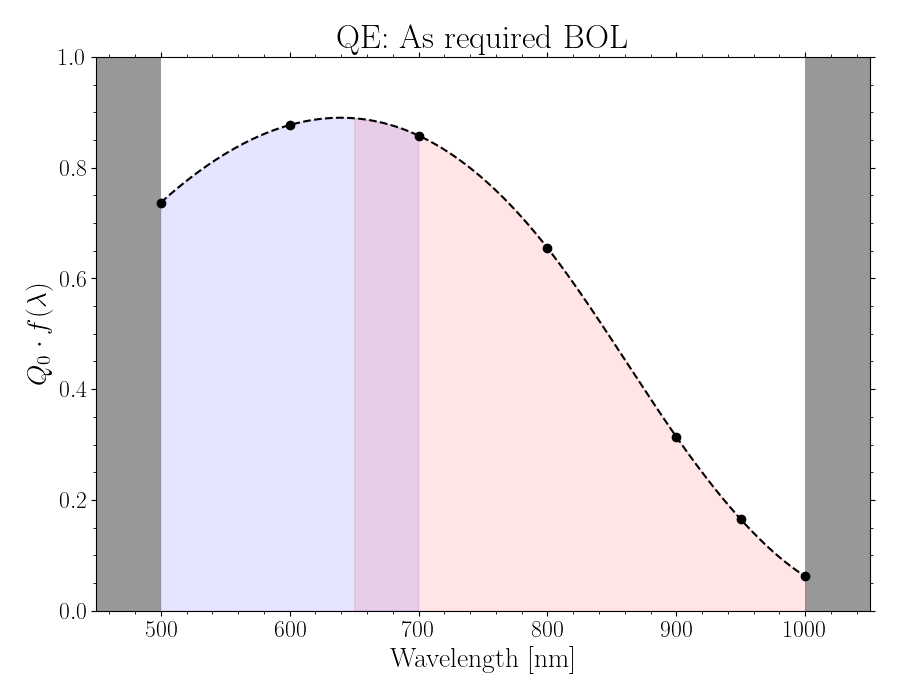

In [46]:
wl = np.array([500,   600,   700,   800,   900,   950,  1000])
QE = np.array([0.737, 0.877, 0.858, 0.655, 0.314, 0.165, 0.062])
grid_no = 1000

wl_int = np.linspace(wl[0], wl[-1], grid_no)                                                                                                                                         
spline = scipy.interpolate.make_interp_spline(wl, QE, k=3)                                                                                                                                             
QE_int = spline(wl_int)

dex_650 = ut.findNearestIndex(wl_int, 650)
dex_700 = ut.findNearestIndex(wl_int, 700)

print(dex)
QE_BOL_required_NCAM      = np.trapz(QE_int      / (len(wl) - 1))
QE_BOL_required_FCAM_blue = np.trapz(QE_int[:dex_700] / (len(wl[:dex_700]) - 1))
QE_BOL_required_FCAM_red  = np.trapz(QE_int[dex_650:] / (len(wl[dex_650:]) - 1))

print(f"Wavelength range {wl[0]} - {wl[-1]} nm:")
print(f"As required QE N-CAM     : {QE_BOL_required_NCAM:.4f}")
print(f"As required QE F-CAM blue: {QE_BOL_required_FCAM_blue:.4f}")
print(f"As required QE F-CAM red : {QE_BOL_required_FCAM_red:.4f}")

fig = plt.figure(figsize=(9,7))
plt.axvspan(350, wl[0], facecolor='0.2', alpha=0.5)
plt.axvspan(wl[-1], 1150, facecolor='0.2', alpha=0.5)
plt.fill_between(wl_int[:dex_700], QE_int[:dex_700], color='blue', alpha=.1)
plt.fill_between(wl_int[dex_650:], QE_int[dex_650:], color='red',  alpha=.1)
plt.axhline(y=QE_BOL_required_NCAM,      color='g', linestyle=':', linewidth=2, label = "N-CAM")
plt.axhline(y=QE_BOL_required_FCAM_blue, color='b', linestyle=':', linewidth=2, label = "F-CAM blue")
plt.axhline(y=QE_BOL_required_FCAM_red,  color='r', linestyle=':', linewidth=2, label = "F-CAM red")
plt.plot(wl_int, QE_int, 'k--')
plt.plot(wl, QE, 'ko')

# Axes
plt.title("QE: As required BOL", fontsize = 24)
plt.xlabel("Wavelength [nm]", fontsize = 20)
plt.ylabel(r'$Q_0 \cdot f(\lambda )$', fontsize = 20)
plt.xlim(450, 1050)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Test of spectral response

In [3]:
# Working directory 
workDir = Path(os.getcwd())

# The configurations
inputFile = Path(os.getenv('PLATO_PROJECT_HOME')) / 'inputfiles/inputfile.yaml'

# performance for the simulations
performance = 'required'

In [12]:
# The PLATO magnitudes (Pmag) and corresponding fluxes are taken from PLATO-DLR-PL-TN-0113
cfgs = [{'cam'        : 'N-CAM' , 
         'cfg_file'   : 'inputfile_ncam.yaml',
         'output_dir' : workDir / 'ncam',
         'Vmag'       : np.array([8, 9, 10, 11, 12, 13]),
         'Pmag'       : np.array([7.62, 8.62, 9.62, 10.62, 11.62, 12.62]),
         'flux_simulate_BOL' : np.array([1.84e5, 7.31e4, 2.91e4, 1.16e4, 4.62e3, 1.84e3]),
         'flux_required_BOL' : np.array([1.62e5, 6.44e4, 2.56e4, 1.02e4, 4.06e3, 1.62e3]),
         'flux_required_EOL' : np.array([1.58e5, 6.27e4, 2.50e4, 9.94e4, 3.96e3, 1.58e3]),
        },
        {'cam'        : 'F-CAMb', 
         'cfg_file'   : 'inputfile_fcamb.yaml',
         'output_dir' : workDir / 'fcamb',
         'Vmag'       : np.array([8, 9, 10, 11, 12, 13]),
         'Pmag'       : np.array( [ 7.88, 8.88, 9.88, 10.88, 11.88, 12.88]),
         'flux_simulate_BOL' : np.array([8.38e4, 3.33e4, 1.33e4, 5.28e3, 2.10e3, 8.38e2]),
         'flux_required_BOL' : np.array([6.58e4, 2.62e4, 1.04e4, 4.15e3, 1.65e3, 6.58e2]),
         'flux_required_EOL' : np.array([6.39e4, 2.54e4, 1.01e4, 4.03e3, 1.61e3, 6.39e2]),
        },
        {'cam'        : 'F-CAMr', 
         'cfg_file'   : 'inputfile_fcamr.yaml', 
         'output_dir' : workDir / 'fcamr',
         'Vmag'       : np.array([8, 9, 10, 11, 12, 13]),
         'Pmag'       : np.array( [ 7.40, 8.40, 9.40, 10.40, 11.40, 12.40]),
         'flux_simulate_BOL' : np.array([9.17e4, 3.65e4, 1.45e4, 5.78e3, 2.30e3, 9.17e2]),
         'flux_required_BOL' : np.array([7.41e4, 2.95e4, 1.17e4, 4.68e3, 1.86e3, 7.41e2]),
         'flux_required_EOL' : np.array([7.27e4, 2.89e4, 1.15e4, 4.58e3, 1.83e3, 7.27e2]),
         }]

In [13]:
# Here we generate baseline configuration files using the tools implemented by PlatoSim
for cfg in cfgs:
    
    # we will output the yaml configuration file here
    cfg_file = cfg['output_dir'] / cfg['cfg_file']
    
    # Create output directory for each sim
    if not os.path.isdir(cfg['output_dir']):
        os.mkdir(cfg['output_dir'])
    path = cfg['output_dir']
        
    # we call PlatoSim
    cfg['psim'] = Simulation(cfg['cam'])
    
    # We adjust the reference flux to that of the PLATO passband
    cfg['psim']['ObservingParameters/Fluxm0'] = 0.73244782244e8
    
    # We generate the default configurations
    if cfg['cam'] == 'N-CAM':
        cfg['psim'].useNormalCamera(performance=performance)
    elif cfg['cam'] == 'F-CAMb':
        cfg['psim'].useFastCamera(passband='blue', performance=performance)
    elif cfg['cam'] == 'F-CAMr':
        cfg['psim'].useFastCamera(passband='red', performance=performance)
    else:
        print('### error configuring camera ###')
        break
    
    # we output the default configurations to the yaml files
    cfg['psim'].writeYamlConfigurationFile(cfg_file)
    
    # produce some output
    print('-'*50)
    print('Yaml configuration file for', cfg['cam'], 'printed to', cfg['cfg_file'])
    value = cfg['psim'][ "ObservingParameters/Fluxm0"]
    print('- reference flux     : ', f'{value:.2e}', '[phot/s/m^2/nm]')
    print('- central wavelength : ', cfg['psim'][ "Camera/ThroughputLambdaC"], 'nm')
    print('- bandwith           : ', cfg['psim'][ "Camera/ThroughputBandwidth"], 'nm')
    print('- BOL efficiency     : ', cfg['psim'][ "Telescope/TransmissionEfficiency/BOL"])
    print('- EOL efficiency     : ', cfg['psim'][ "Telescope/TransmissionEfficiency/EOL"])
    print('- mean CCD QE        : ', cfg['psim'][ "CCD/QuantumEfficiency/MeanQuantumEfficiency"])
    print('- telescope group    : ', cfg['psim'][ "Telescope/GroupID"])
    print('- cycle time         : ', cfg['psim'][ "ObservingParameters/CycleTime"], 's')
    print('- readout time       : ', cfg['psim'].getReadoutTime(), 's')

--------------------------------------------------
Yaml configuration file for N-CAM printed to inputfile_ncam.yaml
- reference flux     :  7.32e+07 [phot/s/m^2/nm]
- central wavelength :  550 nm
- bandwith           :  532 nm
- BOL efficiency     :  0.8135
- EOL efficiency     :  0.7945
- mean CCD QE        :  0.6218
- telescope group    :  Custom
- cycle time         :  25 s
- readout time       :  (4.003372000000001, 0) s
--------------------------------------------------
Yaml configuration file for F-CAMb printed to inputfile_fcamb.yaml
- reference flux     :  7.32e+07 [phot/s/m^2/nm]
- central wavelength :  600 nm
- bandwith           :  165 nm
- BOL efficiency     :  0.7899
- EOL efficiency     :  0.7684
- mean CCD QE        :  0.7315
- telescope group    :  Fast
- cycle time         :  2.5 s
- readout time       :  (0.20295, 0.026454000000000002) s
--------------------------------------------------
Yaml configuration file for F-CAMr printed to inputfile_fcamr.yaml
- reference fl

In [14]:
# Here we extract the fluxes simulated with PlatoSim and compare with the tabulated values
counter = 0

for cfg in cfgs:
    print('-'*20)
    print('Camera', cfg['cam'])
    
    # Initialize flux
    cfg['flux'] = []
    v = cfg['Vmag']
    
    # Run for all magnitudes
    for i in range(len(v)):
        
        # Configure simulation
        outputFileName = cfg['cam'] + '_' + str(v[i])
        cfg_file = cfg['output_dir'] / cfg['cfg_file']
        cfg['psim'] = Simulation(outputFileName, configurationFile=cfg_file, outputDir=path)
    
        # Set up out subfield
        cfg['psim']["SubField/ZeroPointRow"]    = 3000
        cfg['psim']["SubField/ZeroPointColumn"] = 3000
        cfg['psim']["SubField/NumColumns"]      = 10
        cfg['psim']["SubField/NumRows"]         = 10
    
        # My PlatoSim doesn't like this to be set to 'Custom'
        cfg['psim']['CCD/Position'] = 2
    
        # Build our catalog
        row = np.array([5.]) + cfg['psim']["SubField/ZeroPointRow"]
        col = np.array([5.]) + cfg['psim']["SubField/ZeroPointColumn"]
        mag = np.array([cfg['Pmag'][i]])
        ID  = np.array([0])

        # Automatic catalogue file creation
        starcatFile = cfg['output_dir'] / f'starcat_{cfg["cam"]}.txt'
        cfg['psim'].createStarCatalogFileFromPixelCoordinates(row, col, mag, ID, starcatFile)
        cfg['psim']["ObservingParameters/NumExposures"] = 1
    
        # Photometry file creation
        photometryFile = cfg['output_dir'] / f'photometry_{cfg["cam"]}_{str(v[i])}.txt'
        cfg['psim'].createPhotometryFile( ID, photometryFile)

        f = cfg['psim'].run(removeOutputFile=True)
    
        # Append flux obtained through PlatoSim's Photometry library
        cfg['flux'].append(f.getFlux(0)[0])
        counter += 1
        print(counter, 'printed output to', photometryFile) 

--------------------
Camera N-CAM
1 printed output to /lhome/nicholas/software/PlatoSim3/docs/issues/issue_1043_spectralResponse/ncam/photometry_N-CAM_8.txt
2 printed output to /lhome/nicholas/software/PlatoSim3/docs/issues/issue_1043_spectralResponse/ncam/photometry_N-CAM_9.txt
3 printed output to /lhome/nicholas/software/PlatoSim3/docs/issues/issue_1043_spectralResponse/ncam/photometry_N-CAM_10.txt
4 printed output to /lhome/nicholas/software/PlatoSim3/docs/issues/issue_1043_spectralResponse/ncam/photometry_N-CAM_11.txt
5 printed output to /lhome/nicholas/software/PlatoSim3/docs/issues/issue_1043_spectralResponse/ncam/photometry_N-CAM_12.txt
6 printed output to /lhome/nicholas/software/PlatoSim3/docs/issues/issue_1043_spectralResponse/ncam/photometry_N-CAM_13.txt
--------------------
Camera F-CAMb
7 printed output to /lhome/nicholas/software/PlatoSim3/docs/issues/issue_1043_spectralResponse/fcamb/photometry_F-CAMb_8.txt
8 printed output to /lhome/nicholas/software/PlatoSim3/docs/issu

In [15]:
def compare_results(cfgs, flux_table):
    
    # the units should be consistent
    for cfg in cfgs:
        data = {'Pmag':cfg['Pmag'], 
                'tabulated_flux':cfg[flux_table], 
                'platosim_flux':cfg['flux']}
        df = pd.DataFrame(data=data)
        output_file_name = cfg['output_dir'] / f'{cfg["cam"]}_spectral_response.csv'
        df.to_csv(output_file_name, index = False)

    print('Flux ratio computed by PlatoSim and tabulated in PLATO-DLR-PL-TN-0113')
    print('N-CAM, F-CAM blue,  F-CAM red')
    print(np.array((cfgs[0]['flux']/cfgs[0][flux_table], 
                    cfgs[1]['flux']/cfgs[1][flux_table], 
                    cfgs[2]['flux']/cfgs[2][flux_table])).T)

In [16]:
compare_results(cfgs, 'flux_simulate_BOL')

Flux ratio computed by PlatoSim and tabulated in PLATO-DLR-PL-TN-0113
N-CAM, F-CAM blue,  F-CAM red
[[0.9357196  0.47996545 0.96052952]
 [0.93258223 0.48159002 0.96800929]
 [0.92730061 0.47899903 0.96979768]
 [0.90054774 0.4806823  0.96732096]
 [0.84960912 0.47210951 0.97310928]
 [0.79149485 0.51188386 0.91404601]]


In [17]:
compare_results(cfgs, 'flux_required_BOL')

Flux ratio computed by PlatoSim and tabulated in PLATO-DLR-PL-TN-0113
N-CAM, F-CAM blue,  F-CAM red
[[1.06279263 0.61126299 1.18867148]
 [1.05856772 0.61209724 1.19770641]
 [1.05407998 0.61256607 1.20188601]
 [1.02415234 0.61156688 1.19468272]
 [0.96679659 0.60086665 1.20330718]
 [0.89898181 0.65191288 1.13114736]]


In [18]:
compare_results(cfgs, 'flux_required_EOL')

Flux ratio computed by PlatoSim and tabulated in PLATO-DLR-PL-TN-0113
N-CAM, F-CAM blue,  F-CAM red
[[1.08969878 0.62943826 1.21156199]
 [1.08726892 0.6313759  1.22257229]
 [1.0793779  0.6307611  1.22278838]
 [0.1050941  0.62977731 1.2207675 ]
 [0.99121064 0.61579501 1.22303353]
 [0.92174084 0.67129683 1.15293011]]
